# 03 - Avaliacao do Modelo

**FarmTech Solutions / Fase 4 CAP 1**

Avalia o modelo salvo no conjunto de teste (mesmo split, `random_state=42`).
Metricas: MAE, MSE, RMSE, R2. Inclui grafico real vs predito, analise de
residuos e importancia das variaveis.

In [1]:
import sys
from pathlib import Path
DATA_DIR = Path.cwd().parent / 'data'
if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))
import feature_engineering as fe

import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
MODELS_DIR = Path.cwd() / 'models'

modelo = joblib.load(MODELS_DIR / 'modelo_farmtech.pkl')
meta = json.load(open(MODELS_DIR / 'model_columns.json', encoding='utf-8'))
print('Modelo:', meta['melhor_modelo'])

df = fe.carregar_dados()
X, y = fe.separar_xy(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

Modelo: Polynomial(grau2)+Ridge


## Metricas no conjunto de teste

In [2]:
y_pred = modelo.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
pd.DataFrame([{'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}]).round(4)

,MAE,MSE,RMSE,R2
0,145.1592,37277.4559,193.0737,0.9659


## Real vs Predito

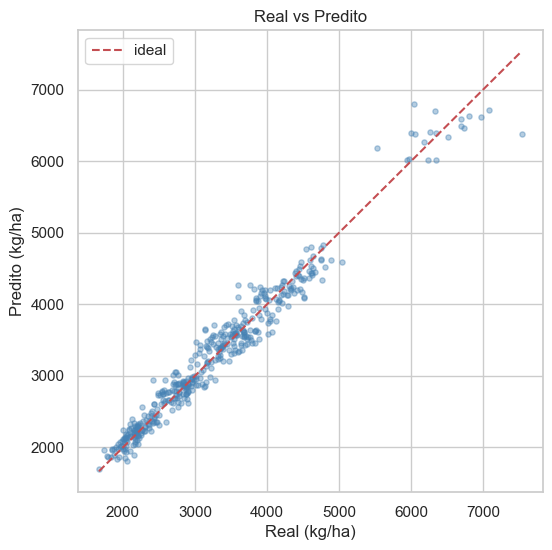

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=14, alpha=0.4, color='steelblue')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='ideal')
ax.set_xlabel('Real (kg/ha)')
ax.set_ylabel('Predito (kg/ha)')
ax.set_title('Real vs Predito')
ax.legend()
plt.show()

## Analise de residuos

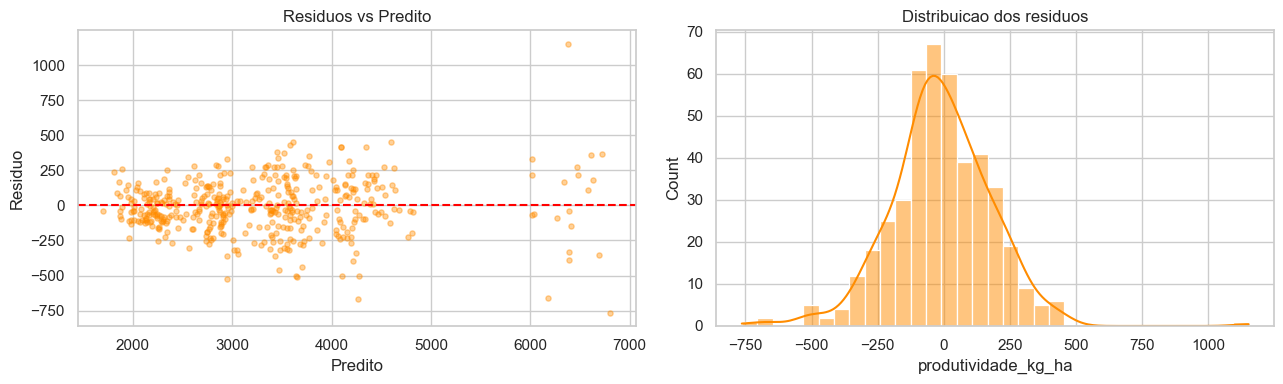

In [4]:
residuos = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred, residuos, s=14, alpha=0.4, color='darkorange')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs Predito')
sns.histplot(residuos, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribuicao dos residuos')
plt.tight_layout()
plt.show()

## Importancia das variaveis

Valida apenas para modelos baseados em arvore.

In [5]:
model = modelo.named_steps['model']
if hasattr(model, 'feature_importances_'):
    nomes = modelo.named_steps['prep'].get_feature_names_out()
    imp = (pd.Series(model.feature_importances_, index=nomes)
             .sort_values(ascending=False).head(12))
    fig, ax = plt.subplots(figsize=(9, 5))
    imp.iloc[::-1].plot.barh(ax=ax, color='seagreen')
    ax.set_title('Top 12 variaveis por importancia')
    plt.tight_layout()
    plt.show()
else:
    print('Modelo sem feature_importances_ (linear).')

Modelo sem feature_importances_ (linear).


## Nota sobre o R2

O alvo `produtividade_kg_ha` e sintetico, derivado das proprias variaveis em
`generate_dataset.py` (ver `src/sql/README_SQL.md`). Por isso o R2 tende a ser
alto: e consequencia do desenho do dataset, nao de overfitting. O objetivo
aqui e demonstrar o pipeline completo de regressao (treino, validacao,
metricas, residuos), nao afirmar valores reais de produtividade.